In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
df=pd.read_csv("C:\\Users\\abdul\\Downloads\\fifa_eda.csv")

In [3]:
df.isnull().mean()*100

ID                          0.000000
Name                        0.000000
Age                         0.000000
Nationality                 0.000000
Overall                     0.000000
Potential                   0.000000
Club                        1.323667
Value                       1.384083
Wage                        0.000000
Preferred Foot              0.000000
International Reputation    0.263635
Skill Moves                 0.263635
Position                    0.000000
Joined                      0.000000
Contract Valid Until        1.587302
Height                      0.000000
Weight                      0.000000
Release Clause              0.000000
dtype: float64

In [4]:
df.duplicated().any()

False

In [5]:
df

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,2.0,CM,2017,2019-01-01,5.750000,134.0,143.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,2.0,ST,2018,2020-01-01,6.250000,170.0,113.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,2.0,ST,2017,2021-01-01,5.666667,148.0,165.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,RW,2018,2019-01-01,5.833333,154.0,143.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        18207 non-null  int64         
 1   Name                      18207 non-null  category      
 2   Age                       18207 non-null  int64         
 3   Nationality               18207 non-null  category      
 4   Overall                   18207 non-null  int64         
 5   Potential                 18207 non-null  int64         
 6   Club                      18207 non-null  category      
 7   Value                     18207 non-null  int32         
 8   Wage                      18207 non-null  int32         
 9   Preferred Foot            18207 non-null  category      
 10  International Reputation  18207 non-null  int32         
 11  Skill Moves               18207 non-null  int32         
 12  Position          

In [7]:
df['Preferred Foot'].unique()

array(['Left', 'Right'], dtype=object)

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df["Value"] =df["Value"].astype(int)
df["Wage"] =df["Wage"].astype(int)
df["International Reputation"] =df["International Reputation"].astype(int)
df["Skill Moves"] =df["Skill Moves"].astype(int)
df["Release Clause"] =df["Release Clause"].astype(int)
df["Weight"] =df["Weight"].astype(int)

In [10]:
df["Name"] =df["Name"].astype("category")
df["Nationality"] =df["Nationality"].astype("category")
df["Club"] =df["Club"].astype("category")
df["Preferred Foot"] =df["Preferred Foot"].astype("category")
df["Position"] =df["Position"].astype("category")

In [11]:
df['Contract Valid Until'] = df['Contract Valid Until'].fillna(df['Contract Valid Until'].mode()[0])
df['Club'] = df['Club'].fillna(df['Club'].mode()[0])

In [12]:
df['Contract Valid Until']=pd.to_datetime(df['Contract Valid Until'])

In [42]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,18207.0,214298.338606,16.0,200315.5,221759.0,236529.5,246620.0,29965.244204
Age,18207.0,25.122206,16.0,21.0,25.0,28.0,45.0,4.669943
Overall,18207.0,66.238699,46.0,62.0,66.0,71.0,94.0,6.90893
Potential,18207.0,71.307299,48.0,67.0,71.0,75.0,95.0,6.136496
Value,18207.0,2444.522876,10.0,325.0,700.0,2200.0,118500.0,5587.638395
Wage,18207.0,9.731312,0.0,1.0,3.0,9.0,565.0,21.99929
International Reputation,18207.0,1.112924,1.0,1.0,1.0,1.0,5.0,0.393554
Skill Moves,18207.0,2.360356,1.0,2.0,2.0,3.0,5.0,0.755394
Joined,18207.0,2016.420607,1991.0,2016.0,2017.0,2018.0,2018.0,2.018194
Contract Valid Until,18207,2020-03-01 06:31:01.393969152,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2026-01-01 00:00:00,NaN


In [13]:
df.isnull().mean()*100

ID                          0.0
Name                        0.0
Age                         0.0
Nationality                 0.0
Overall                     0.0
Potential                   0.0
Club                        0.0
Value                       0.0
Wage                        0.0
Preferred Foot              0.0
International Reputation    0.0
Skill Moves                 0.0
Position                    0.0
Joined                      0.0
Contract Valid Until        0.0
Height                      0.0
Weight                      0.0
Release Clause              0.0
dtype: float64

In [15]:
df = df.round(2)  

In [48]:
df["Contract Valid Until"] = pd.to_datetime(df["Contract Valid Until"])
df["Contract_End_Year"] = df["Contract Valid Until"].dt.year


In [49]:
df

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause,Contract_End_Year
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500,565,Left,5,4,RF,2004,2021-01-01,5.58,159,226500,2021
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000,405,Right,5,5,ST,2018,2022-01-01,6.17,183,127100,2022
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500,290,Right,5,5,LW,2017,2022-01-01,5.75,150,228100,2022
3,193080,De Gea,27,Spain,91,93,Manchester United,72000,260,Right,4,1,GK,2011,2020-01-01,6.33,168,138600,2020
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000,355,Right,4,4,RCM,2015,2023-01-01,5.92,154,196400,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60,1,Right,1,2,CM,2017,2019-01-01,5.75,134,143,2019
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60,1,Right,1,2,ST,2018,2020-01-01,6.25,170,113,2020
18204,241638,B. Worman,16,England,47,67,Cambridge United,60,1,Right,1,2,ST,2017,2021-01-01,5.67,148,165,2021
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60,1,Right,1,2,RW,2018,2019-01-01,5.83,154,143,2019


In [50]:
def country(x):
    return df[df['Nationality'] == x]

In [51]:
country("Portugal")

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause,Contract_End_Year
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000,405,Right,5,5,ST,2018,2022-01-01,6.17,183,127100,2022
56,218667,Bernardo Silva,23,Portugal,86,91,Manchester City,59500,180,Left,2,4,RW,2017,2022-01-01,5.67,141,114500,2022
108,120533,Pepe,35,Portugal,85,85,Beşiktaş JK,9000,57,Right,4,2,RCB,2017,2019-01-01,6.17,179,17100,2019
114,212198,Bruno Fernandes,23,Portugal,84,88,Sporting CP,40500,22,Right,2,4,LCM,2017,2023-01-01,5.83,152,84000,2023
120,207566,William Carvalho,26,Portugal,84,86,Real Betis,31500,38,Right,3,3,CDM,2018,2023-01-01,6.17,183,68500,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15350,230930,Nuno Malheiro,24,Portugal,59,63,Zagłębie Sosnowiec,170,1,Left,1,2,LB,2017,2020-01-01,5.58,152,242,2020
15577,237704,João Virgínia,18,Portugal,59,76,Everton,260,2,Right,1,1,GK,2018,2021-01-01,6.25,176,657,2021
15587,237966,Paulo Alves,20,Portugal,59,70,Wolverhampton Wanderers,260,6,Right,1,3,CM,2018,2020-01-01,5.75,159,546,2020
15916,240950,Pedro Gonçalves,20,Portugal,58,74,Wolverhampton Wanderers,280,6,Right,1,3,CM,2017,2019-01-01,5.67,154,707,2019


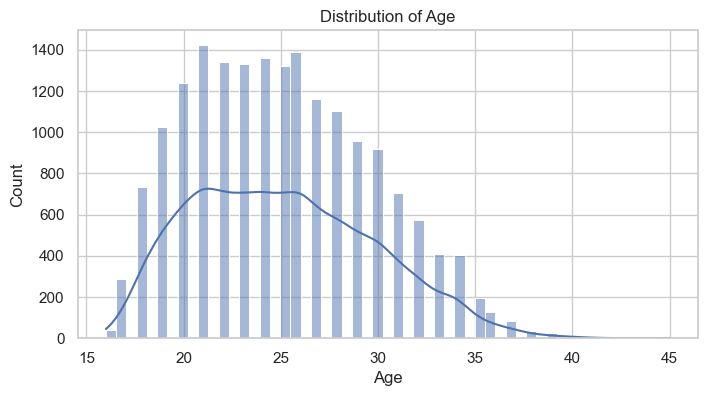

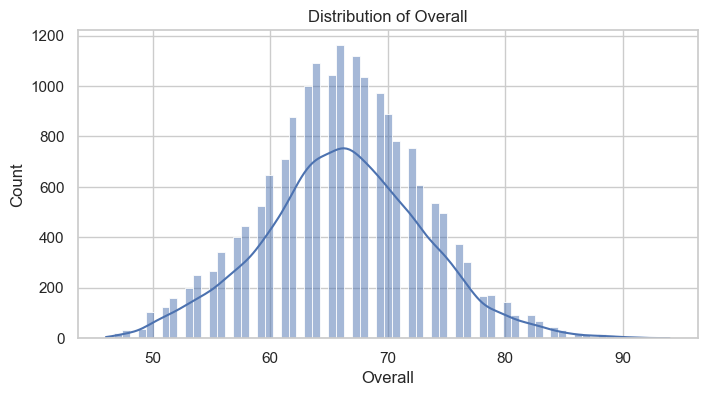

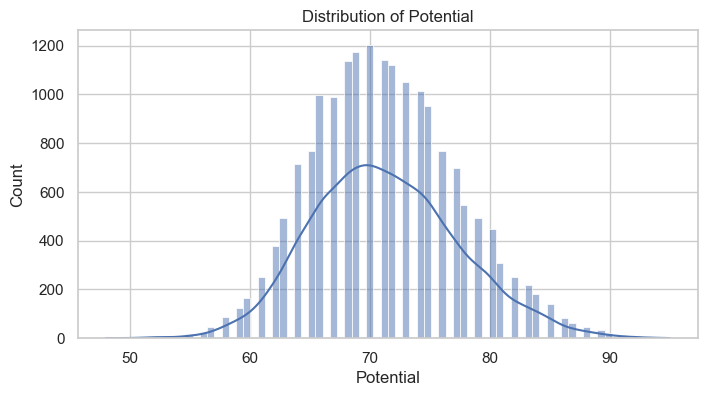

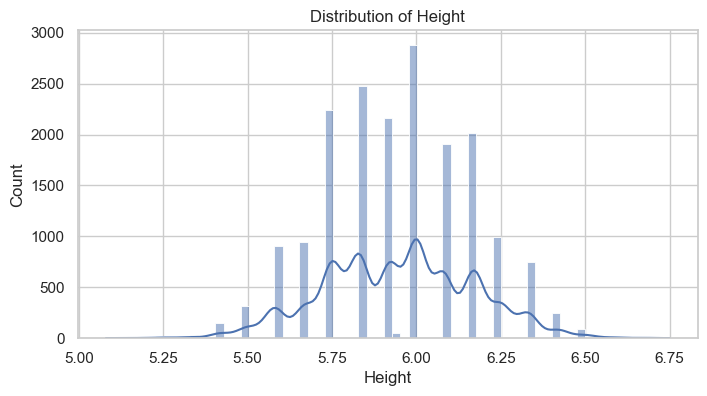

In [37]:
# Univariate Analysis

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['ID', 'Joined'], errors='ignore')

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


<Axes: ylabel='Age'>

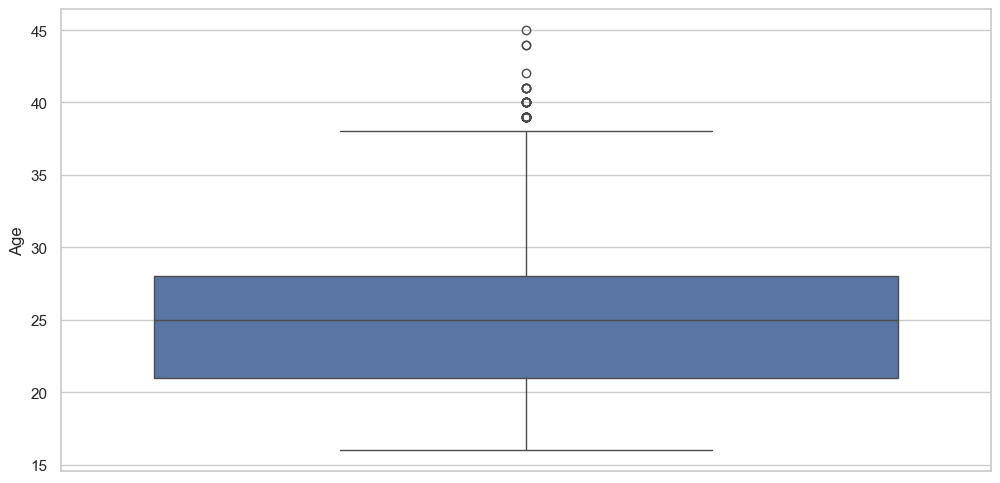

In [43]:
sns.boxplot(df["Age"])

In [45]:
df["Preferred Foot"].value_counts(normalize=True) * 100

Preferred Foot
Right    76.871533
Left     23.128467
Name: proportion, dtype: float64

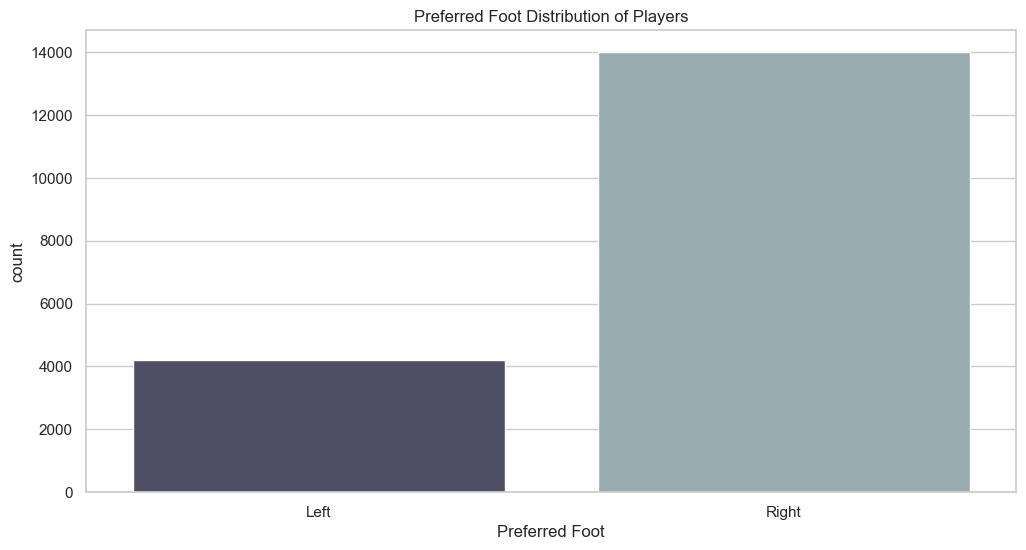

In [46]:
sns.countplot(
    data=df,
    x='Preferred Foot',
    hue='Preferred Foot',
    palette='bone',
    legend=False
)
plt.title('Preferred Foot Distribution of Players')
plt.show()


In [ ]:
# Majority of players are right-footed

# Left-footed players are significantly fewer

# Indicates a talent imbalance, which is valuable for scouting and team composition analysis

# 📌 Power BI equivalent: Column chart + slicer on Preferred Foot

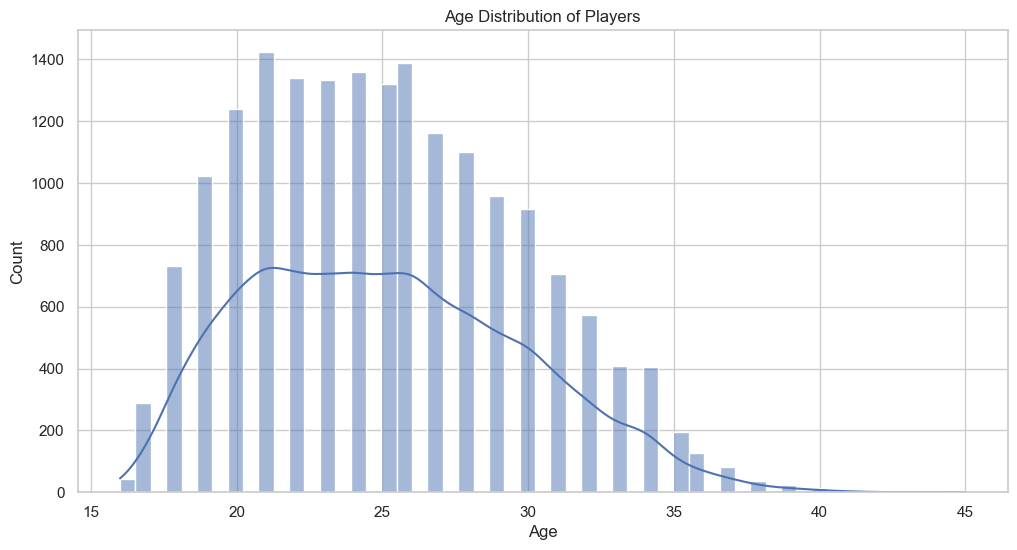

In [47]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution of Players')
plt.show()

In [ ]:
# Player ages are right-skewed

# Most players fall between 20–30 years

# Very few players above 35

# Indicates a young-dominated dataset, common in professional football

# 📌 Business insight: Teams focus on younger, longer-term assets

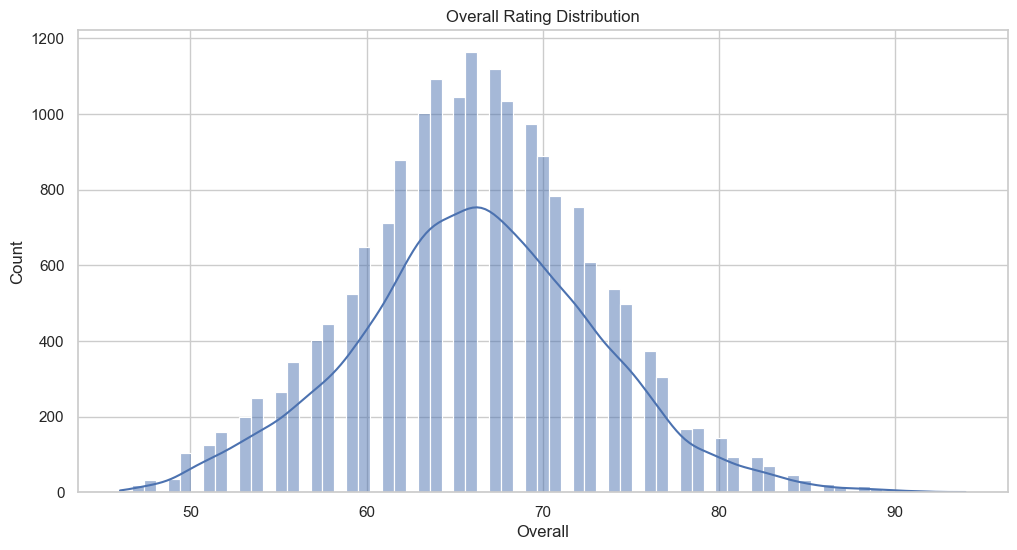

In [52]:
sns.histplot(df['Overall'], kde=True)
plt.title('Overall Rating Distribution')
plt.show()

In [ ]:
# Overall ratings follow a near-normal distribution

# Majority of players are rated between 65–75

# Very few elite players (90+)

# 📌 Industry insight: Elite talent is rare and highly valuable

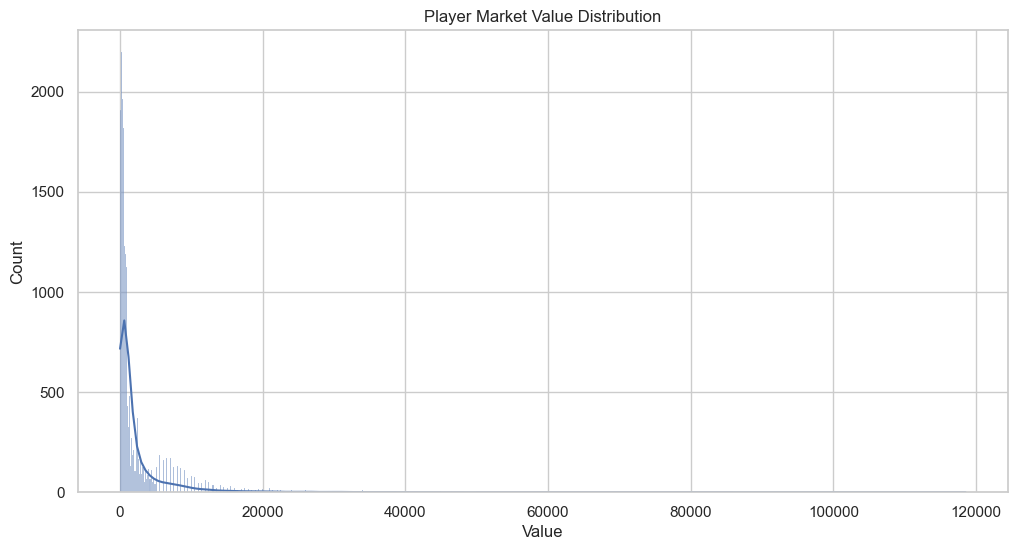

In [53]:
sns.histplot(df['Value'], kde=True)
plt.title('Player Market Value Distribution')
plt.show()

In [ ]:
# Distribution is heavily right-skewed

# Majority of players have low market value

# Few players have extremely high value

# 📌 Industry decision:
# ✔ Use log scale in Power BI
# ✔ High inequality in football economics

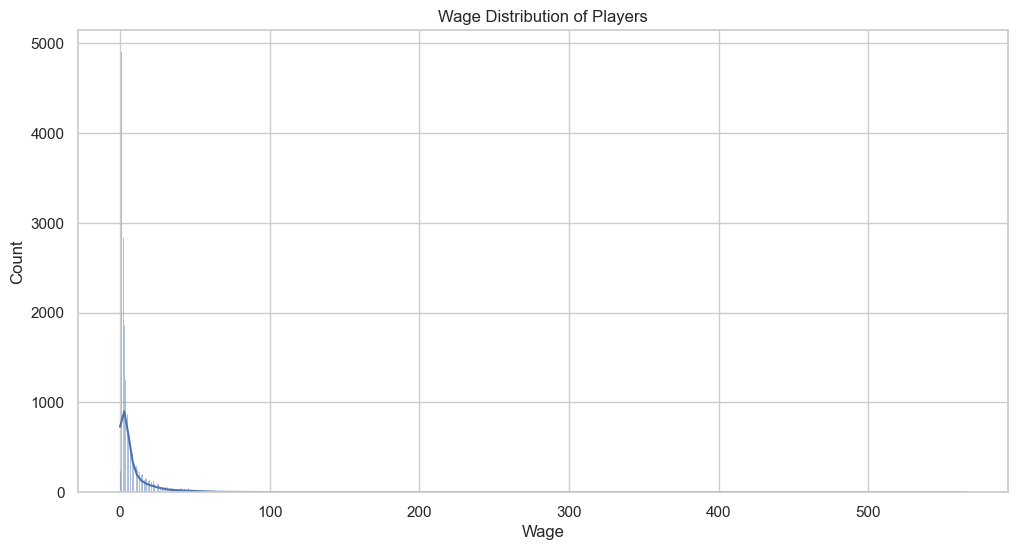

In [54]:
sns.histplot(df['Wage'], kde=True)
plt.title('Wage Distribution of Players')
plt.show()

In [ ]:
# Wage distribution is extremely right-skewed

# Small number of players earn very high wages

# Strong salary inequality exists

# 📌 Business takeaway: Wage structure heavily favors star players

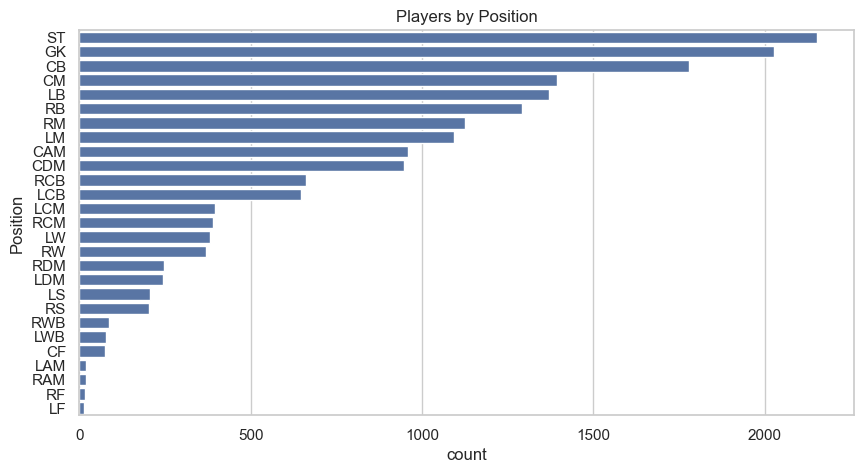

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y='Position',
    order=df['Position'].value_counts().index
)
plt.title('Players by Position')
plt.show()

In [ ]:
# Strikers (ST) are the most represented position.

# Goalkeepers (GK) and Center Backs (CB) also have high counts.

# Midfield roles are significant when combined but not dominant individually.

# Specialized positions (RWB, LWB, RF, LF, RAM, LAM) are rare.

# Distribution reflects real-world squad construction.

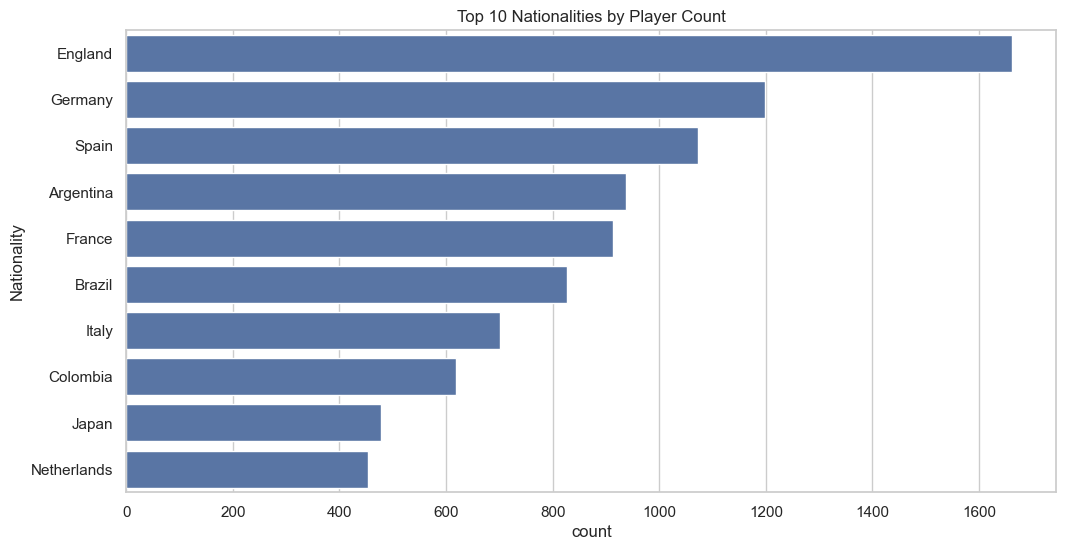

In [56]:
top_nations = df['Nationality'].value_counts().head(10).index

sns.countplot(
    data=df,
    y='Nationality',
    order=top_nations
)
plt.title('Top 10 Nationalities by Player Count')
plt.show()

In [ ]:
# European and South American countries dominate

# Football talent is geographically concentrated

# Useful for scouting and regional analysis

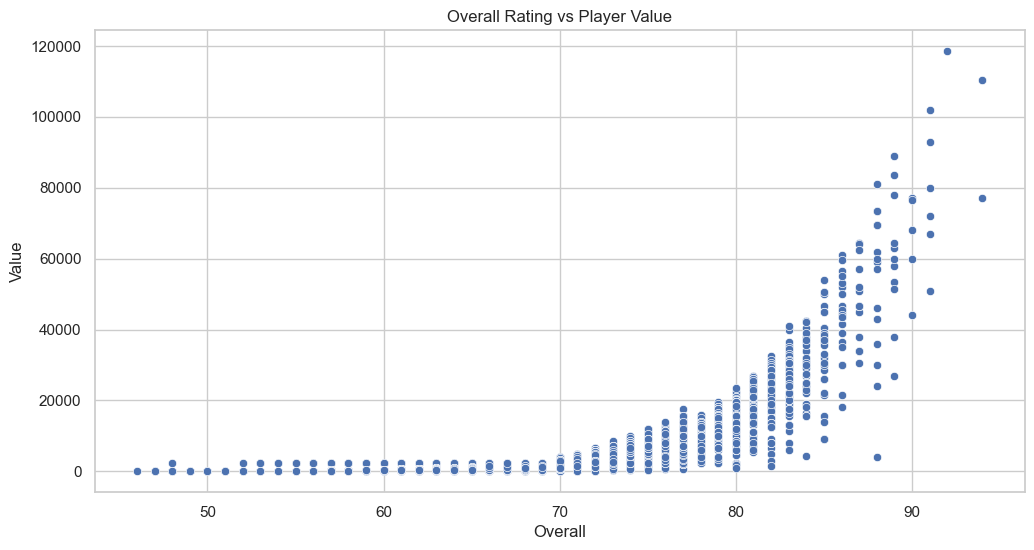

In [58]:
# Bivariate Analysis

sns.scatterplot(data=df, x='Overall', y='Value')
plt.title('Overall Rating vs Player Value')
plt.show()

In [ ]:
# Strong positive correlation

# Higher-rated players command higher market value

# Confirms that performance directly impacts valuation

# 📌 Industry relevance: Pricing and transfer market decisions

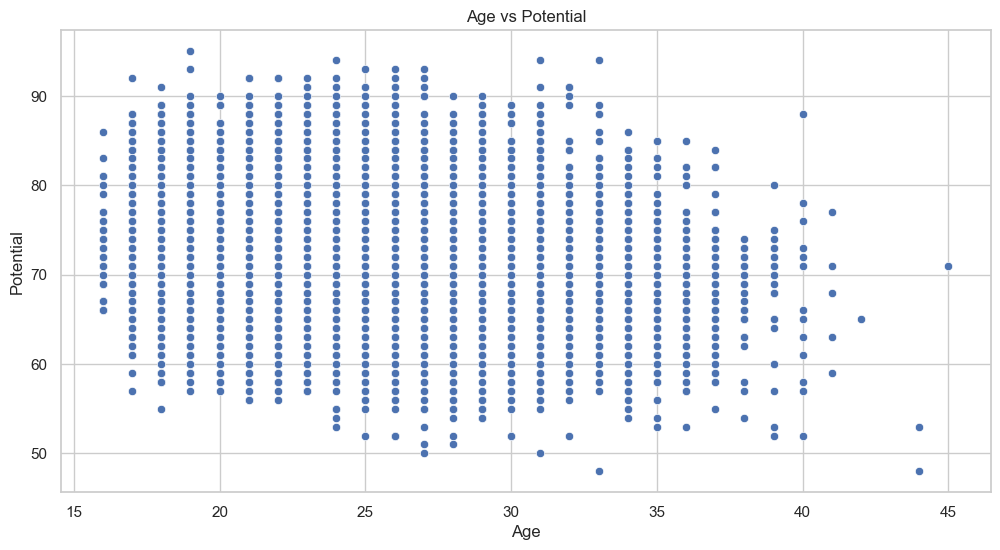

In [59]:
sns.scatterplot(data=df, x='Age', y='Potential')
plt.title('Age vs Potential')
plt.show()

In [ ]:
# Younger players tend to have higher potential

# Potential declines as age increases

# Reinforces importance of youth development

# 📌 Scouting insight: Invest early in young talent

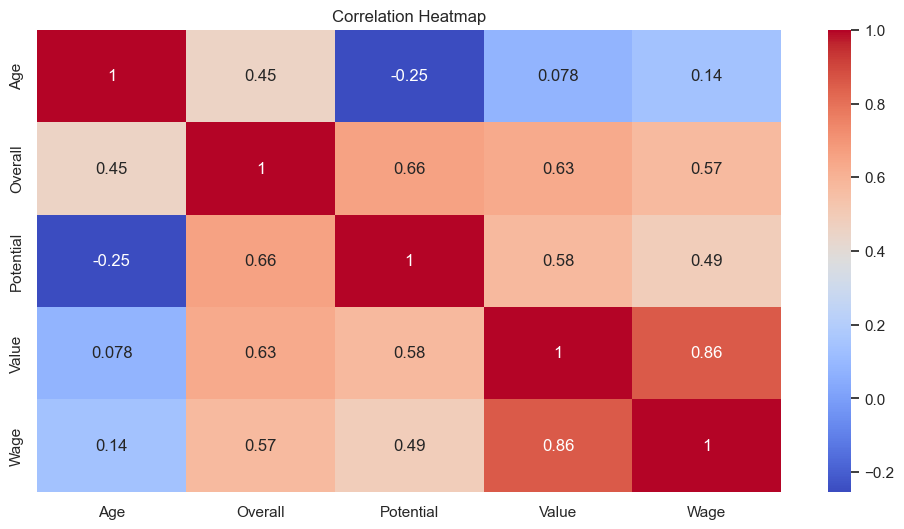

In [60]:
corr = df[['Age','Overall','Potential','Value','Wage']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [62]:
# Overall ↔ Value → strong positive correlation

# Overall ↔ Wage → strong positive correlation

# Age ↔ Potential → negative correlation

# 📌 Executive insight: Performance metrics drive financial outcomes

In [ ]:
# CONCLUSION

# Player performance has a strong impact on market value and wages.

# Younger players tend to have higher potential.

# Player distribution varies significantly by position.

# Right-footed players dominate the dataset.

# Football talent is concentrated in a few countries.

In [65]:
df.to_csv("fifa_eda_final.csv", index=False)